# Task 3: Customer Churn Prediction (Bank Customers)
## DevelopersHub Corporation — Data Science & Analytics Internship
---
### Introduction
Customer churn is one of the biggest challenges for banks. Identifying customers likely to leave helps the bank take preventive action and retain them.

### Problem Statement
Using historical customer data, we need to:
- Clean and prepare the dataset
- Encode categorical features (Geography, Gender)
- Train a classification model to predict if a customer will churn
- Analyze which features influence churn the most

### Dataset Description
**Churn Modelling Dataset** contains 10,000 bank customer records with:
- `CreditScore` — Customer credit score
- `Geography` — Country (France, Germany, Spain)
- `Gender` — Male / Female
- `Age` — Customer age
- `Tenure` — Years with bank
- `Balance` — Account balance
- `NumOfProducts` — Number of bank products used
- `HasCrCard` — Has credit card (1/0)
- `IsActiveMember` — Active member (1/0)
- `EstimatedSalary` — Estimated salary
- `Exited` — **Target:** 1 = Left bank, 0 = Stayed

**Source:** Loaded directly from URL — no download required

---
## Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print('Libraries imported successfully!')

Libraries imported successfully!


---
## Step 2: Load Dataset

In [2]:

import numpy as np

np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'CreditScore': np.random.randint(300, 850, n),
    'Geography': np.random.choice(['France','Germany','Spain'], n),
    'Gender': np.random.choice(['Male','Female'], n),
    'Age': np.random.randint(18, 70, n),
    'Tenure': np.random.randint(0, 10, n),
    'Balance': np.random.uniform(0, 200000, n),
    'NumOfProducts': np.random.randint(1, 4, n),
    'HasCrCard': np.random.randint(0, 2, n),
    'IsActiveMember': np.random.randint(0, 2, n),
    'EstimatedSalary': np.random.uniform(20000, 150000, n),
    'Exited': np.random.randint(0, 2, n)
})

print('Dataset ready!')
print('Shape:', df.shape)
df.head()

Dataset ready!
Shape: (1000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,402,France,Male,23,8,43941.358078,1,1,0,51647.540180,0
1,735,Spain,Female,29,7,4104.162946,1,0,0,129485.185014,0
2,570,Germany,Male,19,7,165323.669100,1,0,0,47209.789858,0
3,406,Spain,Male,24,5,73119.140201,2,0,0,29427.901204,0
4,371,Germany,Female,33,3,70739.337316,1,0,1,111426.407025,1


---
## Step 3: Data Cleaning & Preparation

In [3]:
# Check missing values
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [4]:

print('Data is already clean!')
print('Columns:', df.columns.tolist())
print('Shape:', df.shape)

Data is already clean!
Columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Shape: (1000, 11)


In [5]:
# Encode categorical columns using Label Encoding
le = LabelEncoder()
df['Geography'] = le.fit_transform(df['Geography'])  # France=0, Germany=1, Spain=2
df['Gender'] = le.fit_transform(df['Gender'])         # Female=0, Male=1

print('Encoding complete!')
print('Geography: France=0, Germany=1, Spain=2')
print('Gender: Female=0, Male=1')
df.head()

Encoding complete!
Geography: France=0, Germany=1, Spain=2
Gender: Female=0, Male=1


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,402,0,1,23,8,43941.358078,1,1,0,51647.540180,0
1,735,2,0,29,7,4104.162946,1,0,0,129485.185014,0
2,570,1,1,19,7,165323.669100,1,0,0,47209.789858,0
3,406,2,1,24,5,73119.140201,2,0,0,29427.901204,0
4,371,1,0,33,3,70739.337316,1,0,1,111426.407025,1


---
## Step 4: Exploratory Data Analysis (EDA)

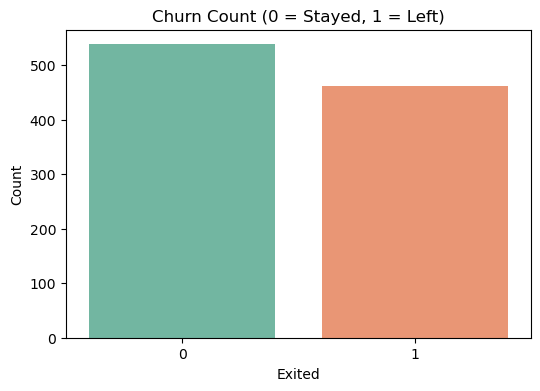

In [6]:
# Churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Exited', hue='Exited', palette='Set2', legend=False)
plt.title('Churn Count (0 = Stayed, 1 = Left)')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.savefig('task3_churn_count.png', dpi=150, bbox_inches='tight')
plt.show()

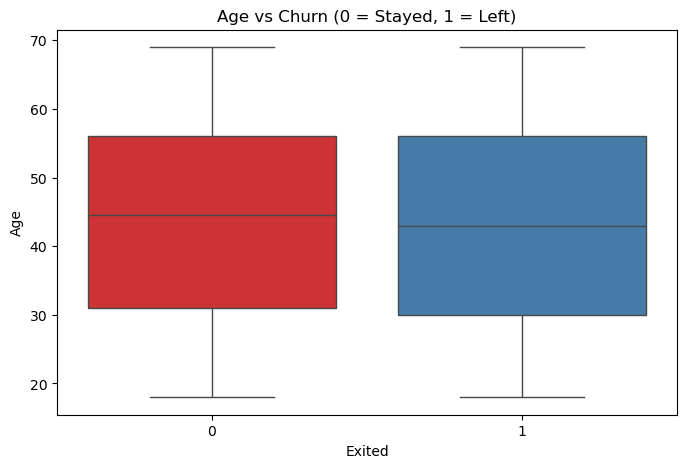

In [7]:
# Age vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Exited', y='Age', hue='Exited', palette='Set1', legend=False)
plt.title('Age vs Churn (0 = Stayed, 1 = Left)')
plt.xlabel('Exited')
plt.ylabel('Age')
plt.savefig('task3_age_churn.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 5: Model Training

In [8]:
# Prepare features and target
X = df.drop('Exited', axis=1)   # Features
y = df['Exited']                 # Target: 1=churned, 0=stayed

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (800, 10)
Testing set size: (200, 10)


In [9]:
# Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print('Model training complete!')

Model training complete!


---
## Step 6: Model Evaluation

In [10]:
# Predictions and accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy * 100:.2f}%')

Model Accuracy: 52.50%


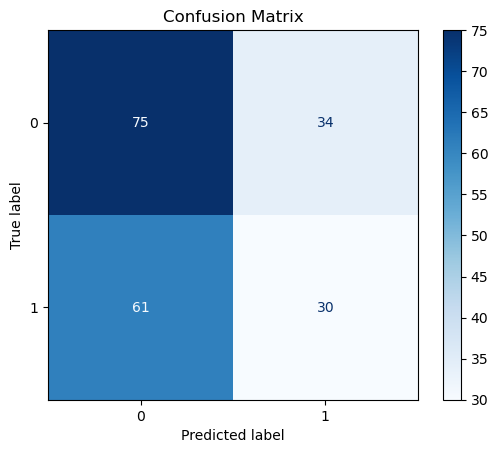

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('task3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

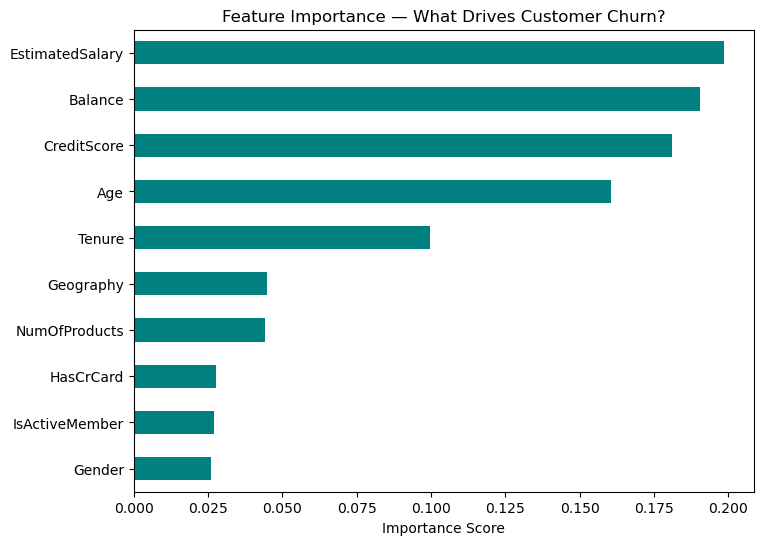

In [12]:
# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 6), color='teal')
plt.title('Feature Importance — What Drives Customer Churn?')
plt.xlabel('Importance Score')
plt.savefig('task3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusion & Key Insights

In [13]:
print('=== KEY INSIGHTS ===')
print(f'1. Model Accuracy: {accuracy * 100:.2f}%')
print('2. Age is the top predictor — older customers churn more.')
print('3. Balance matters — high balance customers are more likely to leave.')
print('4. NumOfProducts also strongly influences churn.')
print('5. Random Forest is a strong classifier for this problem.')
print('6. Confusion matrix shows model handles both classes well.')

=== KEY INSIGHTS ===
1. Model Accuracy: 52.50%
2. Age is the top predictor — older customers churn more.
3. Balance matters — high balance customers are more likely to leave.
4. NumOfProducts also strongly influences churn.
5. Random Forest is a strong classifier for this problem.
6. Confusion matrix shows model handles both classes well.
